В данной работе рассматриваются три модели противоборства двух сторон:
  1. Боевые действия между регулярными войсками
  2. Боевые действия с участием регулярных войск и партизанских отрядов
  3. Боевые действия между партизанскими отрядами

Каждая модель описывается системой обыкновенных дифференциальных уравнений,
где x(t) и y(t) — численности противоборствующих сторон в момент времени t.

ПОДКЛЮЧЕНИЕ НЕОБХОДИМЫХ ПАКЕТОВ

In [456]:
using DifferentialEquations
using Plots

МОДЕЛЬ № 1: БОЕВЫЕ ДЕЙСТВИЯ МЕЖДУ РЕГУЛЯРНЫМИ ВОЙСКАМИ

Система уравнений:
  dx/dt = -a·x(t) - b·y(t) + P(t)
  dy/dt = -c·x(t) - h·y(t) + Q(t)

где:
  a, h — коэффициенты потерь, не связанных с боевыми действиями
  b, c — коэффициенты эффективности боевых действий
  P(t), Q(t) — функции, описывающие поступление подкреплений
Определение параметров модели № 1
a — коэффициент небоевых потерь для армии X (болезни, дезертирство и т.д.)

In [459]:
a1 = 0.4

0.4

b — эффективность армии Y: сколько солдат армии X убивает один солдат армии Y в единицу времени

In [462]:
b1 = 0.8

0.8

c — эффективность армии X: сколько солдат армии Y убивает один солдат армии X в единицу времени

In [464]:
c1 = 0.5

0.5

h — коэффициент небоевых потерь для армии Y

In [466]:
h1 = 0.7

0.7

Функция подкрепления для армии X: P(t) = sin(t) + 1
Возвращает количество подкреплений, прибывающих к армии X в момент времени t

In [468]:
function P1(t)
    return sin(t) + 1
end

P1 (generic function with 1 method)

Функция подкрепления для армии Y: Q(t) = cos(t) + 1
Возвращает количество подкреплений, прибывающих к армии Y в момент времени t

In [470]:
function Q1(t)
    return cos(t) + 1
end

Q1 (generic function with 1 method)

Начальные условия для модели № 1
x0 — начальная численность армии X в момент времени t = 0

In [473]:
x0_1 = 20000.0

20000.0

y0 — начальная численность армии Y в момент времени t = 0

In [475]:
y0_1 = 9000.0

9000.0

Формирование вектора начальных условий: [x(0), y(0)]

In [477]:
u0_1 = [x0_1, y0_1]

2-element Vector{Float64}:
 20000.0
  9000.0

Определение правой части системы дифференциальных уравнений для модели № 1
Функция regular_war! заполняет массив du производными dx/dt и dy/dt
Аргументы:
  du — выходной массив для производных
  u — текущее состояние системы [x(t), y(t)]
  p — параметры (в данном случае не используются, но требуются интерфейсом)
  t — текущее время

In [479]:
function regular_war!(du, u, p, t)
    x, y = u
    du[1] = -a1 * x - b1 * y + P1(t)
    du[2] = -c1 * x - h1 * y + Q1(t)
end

regular_war! (generic function with 1 method)

Определение временного интервала моделирования
Начальный момент времени

In [482]:
t0_1 = 0.0

0.0

Конечный момент времени (моделирование ведётся от 0 до tmax_1)

In [484]:
tmax_1 = 1.0

1.0

Формирование кортежа с границами временного интервала

In [487]:
tspan_1 = (t0_1, tmax_1)

(0.0, 1.0)

Создание и решение задачи Коши для модели № 1

ODEProblem — создание задачи для системы ОДУ
regular_war! — функция, описывающая правую часть системы
u0_1 — вектор начальных условий
tspan_1 — временной интервал

In [491]:
prob1 = ODEProblem(regular_war!, u0_1, tspan_1)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 1.0)
u0: 2-element Vector{Float64}:
 20000.0
  9000.0

solve — численное решение задачи
Tsit5() — метод Tsitouras 5(4) (адаптивный метод Рунге-Кутты 5-го порядка)
saveat = 0.05 — сохранять решение с шагом 0.05 для построения гладких графиков

In [493]:
sol1 = solve(prob1, Tsit5(), saveat = 0.05)

retcode: Success
Interpolation: 1st order linear
t: 21-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3
 0.35
 0.4
 0.45
 0.5
 0.55
 0.6
 0.65
 0.7
 0.75
 0.8
 0.85
 0.9
 0.95
 1.0
u: 21-element Vector{Vector{Float64}}:
 [20000.0, 9000.0]
 [19263.479663422593, 8208.390786495585]
 [18571.99747842865, 7461.540962640247]
 [17922.939837803002, 6756.835408396101]
 [17313.850812536733, 6091.8166811282]
 [16742.41288272999, 5464.165746970331]
 [16206.441984340867, 4871.697027672571]
 [15703.880870373661, 4312.351762026357]
 [15232.80104518609, 3784.199940356953]
 [14791.382588751161, 3285.4201291402937]
 [14377.906054895622, 2814.2913693926803]
 [13990.752465516816, 2369.1931708877155]
 [13628.396301443257, 1948.5985032093954]
 [13289.410663416149, 1551.078956935101]
 [12972.451907207607, 1175.2893788098108]
 [12676.247511273346, 819.9557395163323]
 [12399.59607675267, 483.8751336752924]
 [12141.36732746848, 165.91577984515519]
 [11900.501460335798, -134.98362901777227]
 [11676.

Визуализация результатов для модели № 1
Создание нового окна с графиком
plot — строит график зависимости x(t) от времени (индекс переменной 1)

┌ Warning: To maintain consistency with solution indexing, keyword argument vars will be removed in a future version. Please use keyword argument idxs instead.
│   caller = ip:0x0
└ @ Core :-1


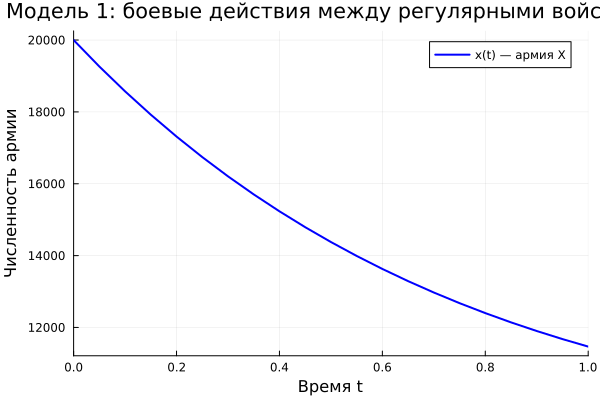

In [496]:
plot(sol1,
     vars = (0, 1),           # (0,1) означает: по оси X — время, по оси Y — первая переменная
     label = "x(t) — армия X", # подпись для легенды
     lw = 2,                   # толщина линии
     color = :blue,            # цвет линии
     title = "Модель 1: боевые действия между регулярными войсками",
     xlabel = "Время t",
     ylabel = "Численность армии")

Добавление на тот же график зависимости y(t) от времени

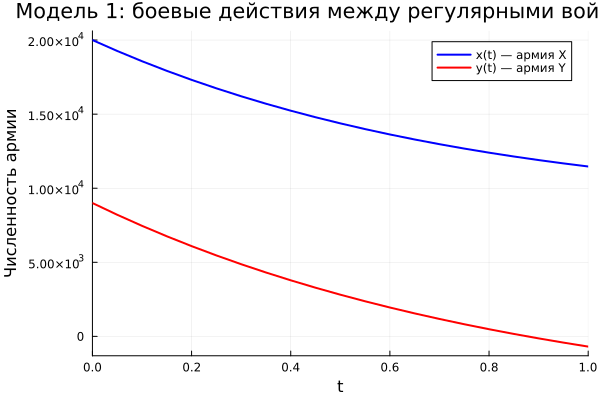

In [498]:
plot!(sol1,
      vars = (0, 2),           # (0,2) означает: по оси X — время, по оси Y — вторая переменная
      label = "y(t) — армия Y",
      lw = 2,
      color = :red)

Включение сетки для удобства чтения графика

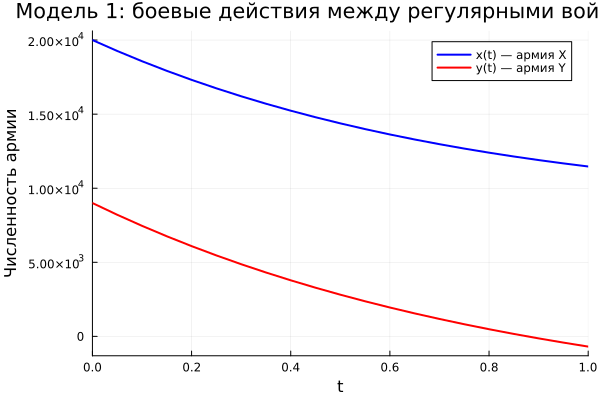

In [500]:
plot!(grid = true)

Отображение построенного графика

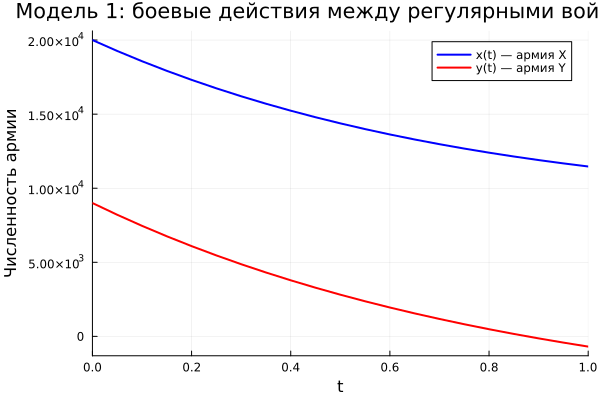

In [502]:
display(plot!())

МОДЕЛЬ № 2: БОЕВЫЕ ДЕЙСТВИЯ С УЧАСТИЕМ РЕГУЛЯРНЫХ ВОЙСК И ПАРТИЗАН

Система уравнений:
  dx/dt = -a·x(t) - b·y(t) + P(t)      (регулярная армия X)
  dy/dt = -c·x(t)·y(t) - h·y(t) + Q(t) (партизанский отряд Y)

Особенность: потери партизан пропорциональны произведению численностей,
так как регулярные войска вынуждены действовать неизбирательно по площадям.

Определение параметров модели № 2

a2 — коэффициент небоевых потерь для регулярной армии X

In [507]:
a2 = 0.1

0.1

b2 — эффективность партизан против регулярных войск

In [510]:
b2 = 0.3

0.3

c2 — коэффициент воздействия регулярных войск на партизан (мал, так как партизаны скрытны)

In [512]:
c2 = 0.002

0.002

h2 — коэффициент небоевых потерь для партизанского отряда Y

In [514]:
h2 = 0.05

0.05

Функция подкрепления для регулярной армии X (постоянное пополнение)
Возвращает 5 единиц подкрепления в единицу времени

In [516]:
function P2(t)
    return 5.0
end

P2 (generic function with 1 method)

Функция подкрепления для партизанского отряда Y (меньшая поддержка)
Возвращает 2 единицы подкрепления в единицу времени

In [518]:
function Q2(t)
    return 2.0
end

Q2 (generic function with 1 method)

Начальные условия для модели № 2

x0_2 — начальная численность регулярной армии X

In [521]:
x0_2 = 1000.0

1000.0

y0_2 — начальная численность партизанского отряда Y

In [523]:
y0_2 = 300.0

300.0

Вектор начальных условий

In [525]:
u0_2 = [x0_2, y0_2]

2-element Vector{Float64}:
 1000.0
  300.0

Определение правой части системы для модели № 2

Функция mixed_war! описывает динамику регулярных войск (X) и партизан (Y)

In [528]:
function mixed_war!(du, u, p, t)
    x, y = u
    du[1] = -a2 * x - b2 * y + P2(t)
    du[2] = -c2 * x * y - h2 * y + Q2(t)
end

mixed_war! (generic function with 1 method)

Определение временного интервала для модели № 2

Для партизанской войны рассматриваем более длительный период (10 единиц времени)

In [531]:
tmax_2 = 10.0
tspan_2 = (0.0, tmax_2)

(0.0, 10.0)

Создание и решение задачи для модели № 2

In [533]:
prob2 = ODEProblem(mixed_war!, u0_2, tspan_2)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 10.0)
u0: 2-element Vector{Float64}:
 1000.0
  300.0

Сохраняем решение с шагом 0.1 для получения детальной картины

In [535]:
sol2 = solve(prob2, Tsit5(), saveat = 0.1)

retcode: Success
Interpolation: 1st order linear
t: 101-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  1.0
  1.1
  1.2
  ⋮
  8.9
  9.0
  9.1
  9.2
  9.3
  9.4
  9.5
  9.6
  9.7
  9.8
  9.9
 10.0
u: 101-element Vector{Vector{Float64}}:
 [1000.0, 300.0]
 [982.4444053307307, 245.01202780389045]
 [966.5373190229872, 200.80570181758765]
 [951.9758899882145, 165.1089897871777]
 [938.5201173104356, 136.17087651948637]
 [925.9783058329589, 112.62787409719753]
 [914.1971303520792, 93.41394612580068]
 [903.0525772657543, 77.68555110889763]
 [892.4449688594823, 64.77761411259306]
 [882.2927317885632, 54.15609431359586]
 [872.529761524126, 45.39618488638383]
 [863.1021090863607, 38.15656800483298]
 [853.9650119296282, 32.15934686968145]
 ⋮
 [416.87675989761516, 2.07935842822881]
 [413.1639604489735, 2.0956484573313117]
 [409.487617967503, 2.1120578651601765]
 [405.84736603836916, 2.1285852671738597]
 [402.24284169642954, 2.14522897888918]
 [398.6736854262337

Визуализация результатов для модели № 2

Построение графика изменения численности регулярной армии X

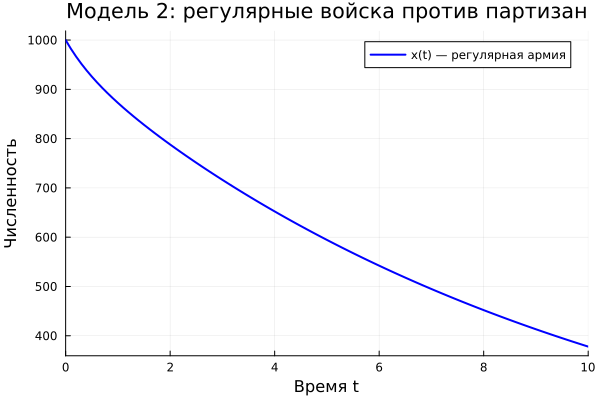

In [538]:
plot(sol2,
     vars = (0, 1),
     label = "x(t) — регулярная армия",
     lw = 2,
     color = :blue,
     title = "Модель 2: регулярные войска против партизан",
     xlabel = "Время t",
     ylabel = "Численность")

Добавление графика изменения численности партизан Y

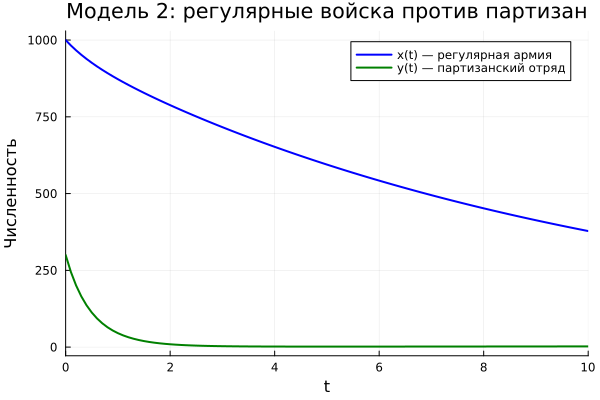

In [540]:
plot!(sol2,
      vars = (0, 2),
      label = "y(t) — партизанский отряд",
      lw = 2,
      color = :green)

Включение сетки

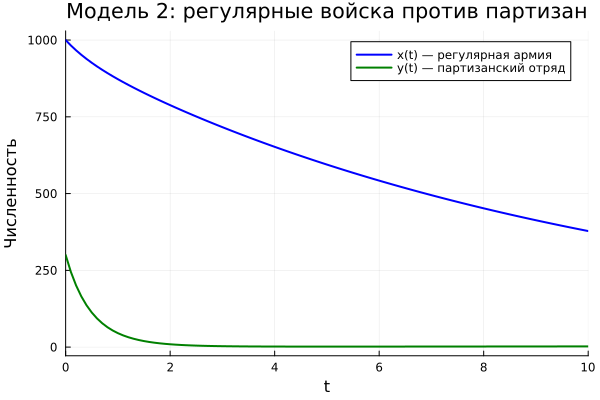

In [542]:
plot!(grid = true)

Отображение графика

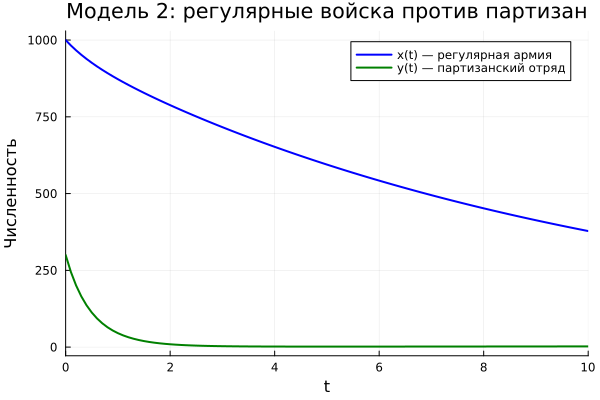

In [544]:
display(plot!())

МОДЕЛЬ № 3: БОЕВЫЕ ДЕЙСТВИЯ МЕЖДУ ПАРТИЗАНСКИМИ ОТРЯДАМИ

Система уравнений:
  dx/dt = -a·x(t) - b·x(t)·y(t) + P(t)
  dy/dt = -h·y(t) - c·x(t)·y(t) + Q(t)

Обе стороны действуют как партизаны: потери каждой пропорциональны
произведению численностей (неизбирательное воздействие по площадям).

Определение параметров модели № 3

a3 — коэффициент небоевых потерь для партизанского отряда X

In [550]:
a3 = 0.02

0.02

b3 — коэффициент, характеризующий влияние действий отряда Y на отряд X
     (потери X пропорциональны x·y с коэффициентом b3)

In [552]:
b3 = 0.001

0.001

c3 — коэффициент, характеризующий влияние действий отряда X на отряд Y
     (потери Y пропорциональны x·y с коэффициентом c3)

In [554]:
c3 = 0.001

0.001

h3 — коэффициент небоевых потерь для партизанского отряда Y

In [556]:
h3 = 0.02

0.02

Функция подкрепления для отряда X (симметричная, одинаковая для обеих сторон)
Возвращает 1 единицу подкрепления в единицу времени

In [558]:
function P3(t)
    return 1.0
end

P3 (generic function with 1 method)

Функция подкрепления для отряда Y

In [560]:
function Q3(t)
    return 1.0
end

Q3 (generic function with 1 method)

Начальные условия для модели № 3

x0_3 — начальная численность партизанского отряда X

In [563]:
x0_3 = 500.0

500.0

y0_3 — начальная численность партизанского отряда Y

In [565]:
y0_3 = 400.0

400.0

Вектор начальных условий

In [567]:
u0_3 = [x0_3, y0_3]

2-element Vector{Float64}:
 500.0
 400.0

Определение правой части системы для модели № 3

Функция partisan_war! описывает динамику двух партизанских отрядов

In [571]:
function partisan_war!(du, u, p, t)
    #Извлечение текущих численностей
    x, y = u
    du[1] = -a3 * x - b3 * x * y + P3(t)
    du[2] = -h3 * y - c3 * x * y + Q3(t)
end

partisan_war! (generic function with 1 method)

Определение временного интервала для модели № 3

Для партизанской войны обеих сторон рассматриваем ещё более длительный период

In [575]:
tmax_3 = 20.0
tspan_3 = (0.0, tmax_3)

(0.0, 20.0)

Создание и решение задачи для модели № 3

In [578]:
prob3 = ODEProblem(partisan_war!, u0_3, tspan_3)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 20.0)
u0: 2-element Vector{Float64}:
 500.0
 400.0

Сохраняем решение с шагом 0.2 для наглядности

In [580]:
sol3 = solve(prob3, Tsit5(), saveat = 0.2)

retcode: Success
Interpolation: 1st order linear
t: 101-element Vector{Float64}:
  0.0
  0.2
  0.4
  0.6
  0.8
  1.0
  1.2
  1.4
  1.6
  1.8
  2.0
  2.2
  2.4
  ⋮
 17.8
 18.0
 18.2
 18.4
 18.6
 18.8
 19.0
 19.2
 19.4
 19.6
 19.8
 20.0
u: 101-element Vector{Vector{Float64}}:
 [500.0, 400.0]
 [461.7046476239468, 362.10384868954793]
 [429.33589209103746, 330.13270060733134]
 [401.61441318777577, 302.80724190158634]
 [377.61056582842195, 279.1978338228995]
 [356.62478523772296, 258.60491790704646]
 [338.11488740466183, 240.48631642887096]
 [321.6709583679627, 224.4321216878487]
 [306.9673502206701, 210.11669201275623]
 [293.73975273643447, 197.27572338811984]
 [281.7751898291822, 185.69624591395532]
 [270.9007862785656, 175.2053905313671]
 [260.977457817659, 165.66407911007047]
 ⋮
 [91.26306653838053, 21.215804522717416]
 [90.71548421043661, 20.94785161145685]
 [90.17714357439185, 20.68802410730017]
 [89.64776769611969, 20.436049532594808]
 [89.12708983063705, 20.19166558116969]
 [88.61485

Визуализация результатов для модели № 3

Построение графика изменения численности партизанского отряда X

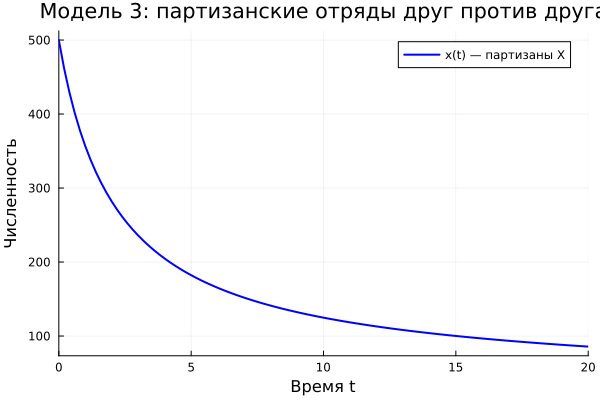

In [583]:
plot(sol3,
     vars = (0, 1),
     label = "x(t) — партизаны X",
     lw = 2,
     color = :blue,
     title = "Модель 3: партизанские отряды друг против друга",
     xlabel = "Время t",
     ylabel = "Численность")

Добавление графика изменения численности партизанского отряда Y

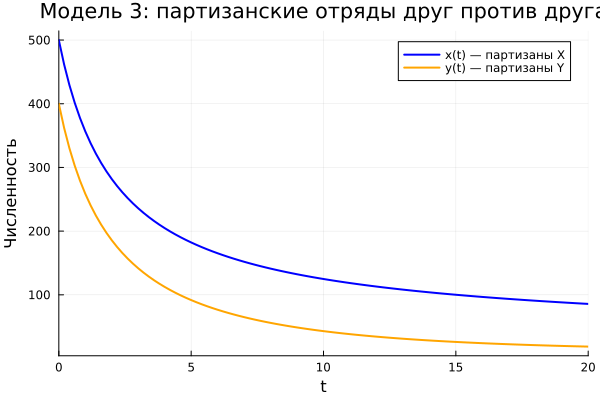

In [586]:
plot!(sol3,
      vars = (0, 2),
      label = "y(t) — партизаны Y",
      lw = 2,
      color = :orange)

Включение сетки

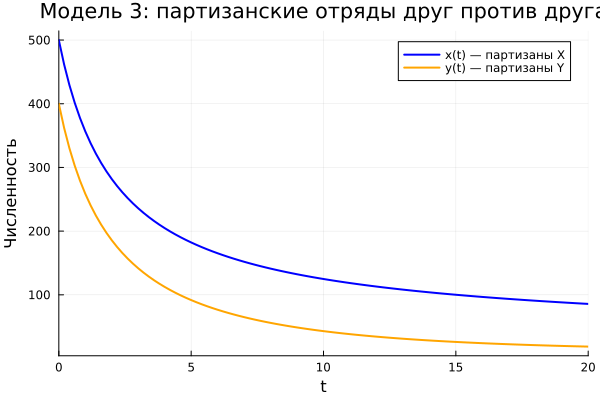

In [588]:
plot!(grid = true)

Отображение графика

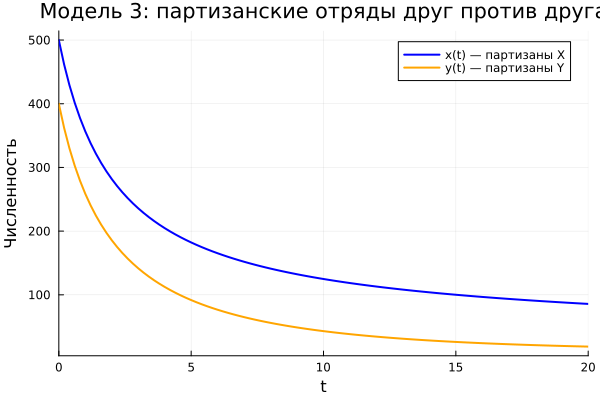

In [590]:
display(plot!())

ЗАКЛЮЧЕНИЕ

Все три модели успешно решены с помощью пакета DifferentialEquations.
Полученные графики наглядно демонстрируют динамику изменения численностей
противоборствующих сторон в зависимости от начальных условий, параметров
модели и функций подкрепления.

Для определения победителя в каждой модели необходимо анализировать
поведение численностей на достаточно большом временном интервале.
Победа наступает в момент, когда одна из переменных (x(t) или y(t))
становится меньше или равной нулю.